# Data Prep — Stage 1: Build `analysis_table`

This notebook builds a unified long-format table indexed by `(subj_id, trial_id, time_bin)` and saves `analysis_table.parquet`.

**Outputs**
- `analysis_table.parquet`
- QC figures and summary tables

**Inputs (expected in working dir)**
- `effort_ts.parquet`
- `pos_ts.parquet`
- `subject_mapping.csv`

**Excluded Participants**
| participantID | Reason |
|---------------|--------|
| `66c3bdcaeef3aa970f90c75e` | Escape time ~2x slower than population (median 13.7s vs 7.2s) |

**Key Columns in Output**

| Column | Description |
|--------|-------------|
| `subj_id` | Subject identifier |
| `trial_id` | Trial identifier |
| `time_bin` | Time bin index |
| `t` | Time in seconds |
| `c_it` | Raw press count per bin |
| `v_t` | Normalized vigor = `(c_it/DT) / f_max_i` |
| `d_t` | Normalized distance to safety |
| `d_t_raw` | Raw distance to safety |
| `threat` | Threat level (0.1, 0.5, 0.9) |
| `choice` | Effort choice (0=low, 1=high) |
| `outcome` | Trial outcome (-1=timeout, 0=escaped, 1=captured) |
| `encounter` | Whether predator appeared (0/1) |
| `encounter_time` | Time of predator encounter |
| `trial_type` | Trial type |
| `trial_end_time` | Time when trial ended |
| `capture_time` | Time of capture (if captured, -1 otherwise) |
| `escape_time` | Time of escape (if escaped, -1 otherwise) |

> Notes
> - Uses a fixed bin width `DT` taken from `effort_ts['window']` if present, otherwise set manually.
> - Models are fit on **raw press counts** (`c_it`) with offsets later; here we also compute normalized vigor `v_t` for plotting.
> - `capture_time` and `escape_time` use -1 as sentinel for "not applicable"

In [1]:
# --- Imports
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

# Optional: nicer plots if available
try:
    import seaborn as sns
    sns.set_context("talk")
except Exception:
    sns = None

# --- Paths (edit if needed)
EFFORT_TS_PATH = "../../data/raw/effort_ts.parquet"
POS_TS_PATH    = "../../data/raw/pos_ts.parquet"
SUBJ_MAP_PATH  = "../../data/raw/subject_mapping.csv"
OUT_PATH       = "../../data/processed/analysis_table.parquet"

assert os.path.exists(EFFORT_TS_PATH), f"Missing {EFFORT_TS_PATH}"
assert os.path.exists(POS_TS_PATH), f"Missing {POS_TS_PATH}"
assert os.path.exists(SUBJ_MAP_PATH), f"Missing {SUBJ_MAP_PATH}"
print("Found input files.")


Found input files.


In [2]:
# --- Load data
# NOTE: requires pyarrow or fastparquet installed.
effort_ts = pd.read_parquet(EFFORT_TS_PATH)
pos_ts    = pd.read_parquet(POS_TS_PATH)
subj_map  = pd.read_csv(SUBJ_MAP_PATH)

print("Loaded effort_ts:", effort_ts.shape)
print("Loaded pos_ts:", pos_ts.shape)
print("Loaded subject_mapping:", subj_map.shape)

print("effort_ts columns:\n", list(effort_ts.columns))
print("pos_ts columns:\n", list(pos_ts.columns))
print("subject_mapping columns:\n", list(subj_map.columns))


Loaded effort_ts: (3498394, 32)
Loaded pos_ts: (10405592, 17)
Loaded subject_mapping: (293, 2)
effort_ts columns:
 ['participantID', 'trialName', 'trial', 'type', 'threat', 'choice', 'outcome', 'startDistance', 'effort_L', 'effort_H', 'distance_L', 'distance_H', 'isAttackTrial', 'calibrationMax', 'predatorSpawnTime', 'encounterTime', 'predatorAttackTime', 'circaStrikeTime', 'strike_time', 'trialEndTime', 'trialCaptureTime', 'trialEscapeTime', 'trialEndTime_raw', 'trialCaptureTime_raw', 'trialEscapeTime_raw', 'window', 'mode', 'bin', 't', 'press_count', 'effort_rel', 'effort_hz']
pos_ts columns:
 ['participantID', 'trialName', 'trial', 'type', 'threat', 'choice', 'outcome', 'startDistance', 'effort_L', 'effort_H', 'distance_L', 'distance_H', 'isAttackTrial', 'agent', 't', 'x', 'y']
subject_mapping columns:
 ['participantID', 'subj']


In [3]:
# --- Participant Exclusions ---
# List of participantIDs to exclude from analysis
# Add participantID strings here with a comment explaining why

EXCLUDED_PARTICIPANTS = [
    # Outlier: escape time ~2x slower than population (median 13.7s vs 7.2s)
    # 74% of trials have trialEndTime > 16s
    "66c3bdcaeef3aa970f90c75e",
]

n_before_eff = len(effort_ts)
n_before_pos = len(pos_ts)

effort_ts = effort_ts[~effort_ts["participantID"].isin(EXCLUDED_PARTICIPANTS)].copy()
pos_ts = pos_ts[~pos_ts["participantID"].isin(EXCLUDED_PARTICIPANTS)].copy()

n_excluded_eff = n_before_eff - len(effort_ts)
n_excluded_pos = n_before_pos - len(pos_ts)

print(f"Excluded {len(EXCLUDED_PARTICIPANTS)} participant(s): {EXCLUDED_PARTICIPANTS}")
print(f"  effort_ts: {n_before_eff:,} → {len(effort_ts):,} rows ({n_excluded_eff:,} removed)")
print(f"  pos_ts:    {n_before_pos:,} → {len(pos_ts):,} rows ({n_excluded_pos:,} removed)")

Excluded 1 participant(s): ['66c3bdcaeef3aa970f90c75e']
  effort_ts: 3,498,394 → 3,485,541 rows (12,853 removed)
  pos_ts:    10,405,592 → 10,368,619 rows (36,973 removed)


## 1) Standardize IDs and merge subject mapping

We map `participantID → subj_id` using `subject_mapping.csv` and create:
- `subj_id`
- `trial_id`
- `time_bin`

In [4]:
# --- Merge subject mapping
# Expect: subject_mapping.csv has columns ['participantID', 'subj']
subj_map = subj_map.rename(columns={"subj": "subj_id"})

# Left-join mapping onto both tables
_eff = effort_ts.merge(subj_map, on="participantID", how="left")
_pos = pos_ts.merge(subj_map, on="participantID", how="left")

# QC: mapping coverage
missing_eff = _eff["subj_id"].isna().mean()
missing_pos = _pos["subj_id"].isna().mean()
print(f"Missing subj_id (effort_ts): {missing_eff:.4%}")
print(f"Missing subj_id (pos_ts):    {missing_pos:.4%}")

# Drop rows without mapping (should be none in a clean pipeline)
_eff = _eff.dropna(subset=["subj_id"]).copy()
_pos = _pos.dropna(subset=["subj_id"]).copy()

# Standardized ids
_eff["subj_id"] = _eff["subj_id"].astype(int)
_pos["subj_id"] = _pos["subj_id"].astype(int)

_eff["trial_id"] = _eff["trial"].astype(int)
_pos["trial_id"] = _pos["trial"].astype(int)

# time bin
_eff["time_bin"] = _eff["bin"].astype(int)

print("After mapping + id standardization:")
print("  effort_ts:", _eff.shape)
print("  pos_ts:", _pos.shape)


Missing subj_id (effort_ts): 0.0000%
Missing subj_id (pos_ts):    0.0000%
After mapping + id standardization:
  effort_ts: (3485541, 35)
  pos_ts: (10368619, 19)


## 2) Define bin width `DT` and build action variables

We create:
- `c_it` = raw press count per bin
- `v_t`  = normalized press rate = `(c_it/DT) / calibrationMax`

We also drop physiologically implausible bins (`c_it > 5` by default).

In [5]:
# --- Bin width
# Prefer reading DT from data; otherwise set manually.
if "window" in _eff.columns:
    # window may be in seconds already (e.g., 0.157). If in ms, convert.
    DT_guess = float(pd.Series(_eff["window"]).dropna().mode().iloc[0])
    DT = DT_guess / 1000.0 if DT_guess > 2 else DT_guess
else:
    DT = 0.157

print("Using DT =", DT)

# --- Actions
_eff = _eff.rename(columns={"press_count": "c_it", "calibrationMax": "f_max_i"})

# Sanity: counts should be integers
# If floats (due to aggregation), keep as float but expect near-integers.

# Drop impossible bins
C_IT_MAX = 5
n_bad = int((_eff["c_it"] > C_IT_MAX).sum())
print(f"Bins with c_it > {C_IT_MAX}: {n_bad}")
_eff = _eff.query("c_it <= @C_IT_MAX").copy()

# Normalized vigor (fraction of max capacity)
# v_t = (Hz / f_max) = (c_it / DT) / f_max
_eff["v_t"] = (_eff["c_it"] / DT) / _eff["f_max_i"]

print(_eff[["c_it", "f_max_i", "v_t"]].describe())


Using DT = 0.157
Bins with c_it > 5: 631
               c_it       f_max_i           v_t
count  3.484910e+06  3.484910e+06  3.484910e+06
mean   5.123647e-01  6.930618e+00  4.919107e-01
std    6.068543e-01  1.395361e+00  6.216946e-01
min    0.000000e+00  1.300000e+00  0.000000e+00
25%    0.000000e+00  6.200000e+00  0.000000e+00
50%    0.000000e+00  7.100000e+00  0.000000e+00
75%    1.000000e+00  8.000000e+00  9.099181e-01
max    5.000000e+00  8.900000e+00  2.449780e+01


## 3) Build state variable `d_t` from positions

We compute distance-to-safety using player positions.

Assumptions (edit if needed):
- Safety is at `(0,0)`.
- Use `agent == 'player'` if present.

We then bin positions into the same `DT` windows and compute mean distance per `(subj_id, trial_id, time_bin)`.


In [6]:
# --- Select player rows
_pos2 = _pos.copy()
if "agent" in _pos2.columns:
    # Common labels: 'player' / 'predator'
    if _pos2["agent"].dtype == object:
        player_mask = _pos2["agent"].str.lower().isin(["player", "p", "subject", "human"])
        if player_mask.mean() < 0.1:
            # fallback: if only two agents, take the one with more rows as player
            vc = _pos2["agent"].value_counts()
            print("agent counts:\n", vc.head())
            # heuristic: assume player is most frequent
            player_val = vc.index[0]
            player_mask = _pos2["agent"] == player_val
        _pos2 = _pos2.loc[player_mask].copy()
    else:
        # numeric agent coding: take agent==0 as player if present else most frequent
        if 0 in set(_pos2["agent"].unique()):
            _pos2 = _pos2.loc[_pos2["agent"] == 0].copy()
        else:
            player_val = _pos2["agent"].value_counts().idxmax()
            _pos2 = _pos2.loc[_pos2["agent"] == player_val].copy()

print("Player pos rows:", _pos2.shape)

# --- Compute distance to safety
# If your safety location is not (0,0), edit here.
_pos2["d_t_raw"] = np.sqrt(_pos2["x"]**2 + _pos2["y"]**2)

# Bin position timestamps into effort bins
# We assume pos_ts['t'] is seconds from effort start. If it's absolute, you'll need to align first.
_pos2["time_bin"] = np.floor(_pos2["t"] / DT).astype(int)

# Aggregate to bin-level distance
pos_binned = (
    _pos2.groupby(["subj_id", "trial_id", "time_bin"], as_index=False)
         .agg(d_t_raw=("d_t_raw", "mean"),
              x_mean=("x", "mean"),
              y_mean=("y", "mean"))
)

print("pos_binned:", pos_binned.shape)
pos_binned.head()


Player pos rows: (8774798, 19)
pos_binned: (1660071, 6)


,subj_id,trial_id,time_bin,d_t_raw,x_mean,y_mean
0,1,0,0,4.692223,-4.653076,-0.604837
1,1,0,1,4.824555,-4.784656,-0.619193
2,1,0,2,4.835636,-4.795691,-0.620260
3,1,0,3,4.836823,-4.796887,-0.620269
4,1,0,4,4.836930,-4.796997,-0.620250


## 4) Merge state + trial-level variables into `analysis_table`

We merge:
- bin-level actions (`c_it`, `v_t`) from `effort_ts`
- bin-level state (`d_t_raw`) from binned `pos_ts`
- trial-level columns (from `effort_ts`, since it already contains them)

We also compute:
- `t` = seconds from effort start (already present)
- `d_t` = normalized distance (`d_t_raw / startDistance`) for cross-trial comparability
- `reward_k` = chosen option value proxy (placeholder; edit if you have a true reward column)
- `encounter` and `encounter_time` if present


In [ ]:
# --- Select and rename trial-level vars from effort_ts
# effort_ts already has many trial-level columns repeated per bin.
trial_cols = [
    "subj_id", "trial_id", "time_bin", "t",
    "threat", "choice", "outcome", "startDistance",
    "effort_L", "effort_H", "distance_L", "distance_H",
    "isAttackTrial", "encounterTime",
    # NEW: trial type and timing columns
    "type",
    "trialEndTime", "trialCaptureTime", "trialEscapeTime",
    # Optional: raw timing columns (if needed for debugging)
    "trialEndTime_raw", "trialCaptureTime_raw", "trialEscapeTime_raw",
]
# Keep only those that exist
trial_cols = [c for c in trial_cols if c in _eff.columns]
print(f"Trial-level columns found: {trial_cols}")

# Core per-bin columns
bin_cols = ["subj_id", "trial_id", "time_bin", "t", "c_it", "v_t", "f_max_i"]

eff_core = _eff[trial_cols + [c for c in bin_cols if c not in trial_cols]].copy()

# Merge distance state
analysis_table = eff_core.merge(pos_binned[["subj_id", "trial_id", "time_bin", "d_t_raw"]],
                               on=["subj_id", "trial_id", "time_bin"],
                               how="left")

# --- Handle missing distance values ---
# Some time bins may not have position data (due to sampling misalignment at trial boundaries)
# Forward-fill within each trial, then backward-fill any leading NaNs
n_missing_before = analysis_table["d_t_raw"].isna().sum()
if n_missing_before > 0:
    print(f"Missing d_t_raw values before filling: {n_missing_before:,} ({100*n_missing_before/len(analysis_table):.2f}%)")

    # Sort by time within each trial before filling
    analysis_table = analysis_table.sort_values(["subj_id", "trial_id", "time_bin"])

    # Forward-fill, then backward-fill within each trial
    analysis_table["d_t_raw"] = (
        analysis_table.groupby(["subj_id", "trial_id"])["d_t_raw"]
        .transform(lambda x: x.ffill().bfill())
    )

    n_missing_after = analysis_table["d_t_raw"].isna().sum()
    print(f"Missing d_t_raw values after filling: {n_missing_after:,}")

    # If still missing (entire trials without position data), fill with startDistance
    if n_missing_after > 0:
        print(f"  -> Filling remaining {n_missing_after:,} with startDistance")
        mask = analysis_table["d_t_raw"].isna()
        analysis_table.loc[mask, "d_t_raw"] = analysis_table.loc[mask, "startDistance"]

# Compute normalized distance (recommended)
analysis_table["d_t"] = analysis_table["d_t_raw"] / analysis_table["startDistance"]

# Ensure consistent naming
analysis_table = analysis_table.rename(columns={
    "threat": "threat",
    "choice": "choice",
    "outcome": "outcome",
    "encounterTime": "encounter_time",
    "isAttackTrial": "encounter",
    # NEW: standardized names for timing columns
    "type": "trial_type",
    "trialEndTime": "trial_end_time",
    "trialCaptureTime": "capture_time",
    "trialEscapeTime": "escape_time",
    "trialEndTime_raw": "trial_end_time_raw",
    "trialCaptureTime_raw": "capture_time_raw",
    "trialEscapeTime_raw": "escape_time_raw",
})

# Reward proxy (EDIT THIS IF YOU HAVE TRUE REWARD MAGNITUDE)
# Here we use effort_L/H as the chosen option value proxy.
if set(["effort_L", "effort_H"]).issubset(analysis_table.columns):
    analysis_table["reward_k"] = np.where(analysis_table["choice"] == 1, 5, 1)
else:
    analysis_table["reward_k"] = np.nan

# Keep required columns first
required = [
    "subj_id", "trial_id", "time_bin", "t",
    "v_t", "d_t", "threat", "choice", "reward_k", "outcome",
    "encounter", "encounter_time",
    # NEW: trial type and timing columns
    "trial_type", "trial_end_time", "capture_time", "escape_time",
]
# Some optional columns may be missing
required_present = [c for c in required if c in analysis_table.columns]

# Add helpful extras at end
extras = [c for c in analysis_table.columns if c not in required_present]
analysis_table = analysis_table[required_present + extras]

print("analysis_table:", analysis_table.shape)
print("Columns:", list(analysis_table.columns))
analysis_table.head()

## 5) Sanity checks (must pass)

### Checks
1. **No impossible counts**: `c_it.max() <= 5`
2. **Mapping coverage**: no missing `subj_id`
3. **Normalized vigor distribution** looks reasonable (mass near 0, tail ~1–2)
4. **Distance traces**: within a trial, `d_t_raw` should generally decrease toward 0

If any check fails, stop and fix before saving.


c_it max: 5
Missingness (fraction) in key columns:
 d_t         0.084389
subj_id     0.000000
trial_id    0.000000
time_bin    0.000000
t           0.000000
v_t         0.000000
threat      0.000000
choice      0.000000
outcome     0.000000
dtype: float64


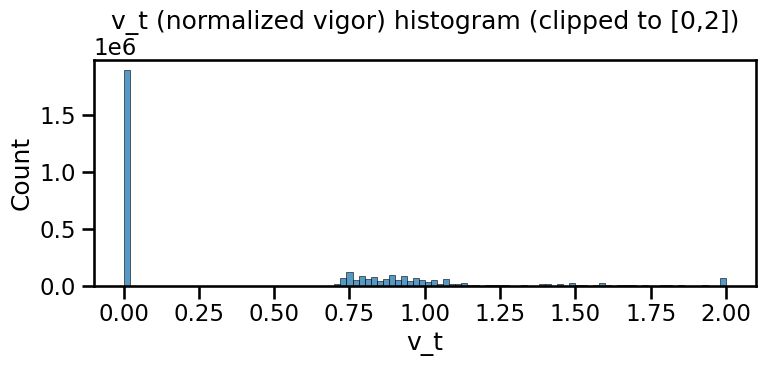

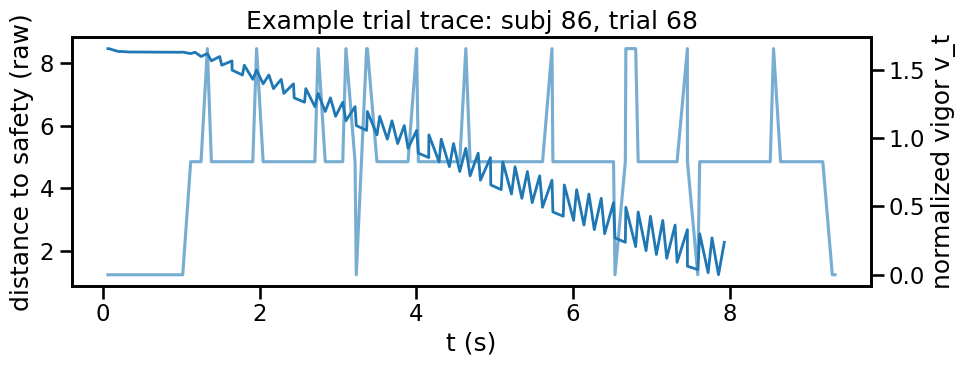

In [8]:
# --- QC 1: counts
print("c_it max:", analysis_table["c_it"].max() if "c_it" in analysis_table.columns else "(missing)")

# --- QC 2: missingness in required columns
req_for_model = ["subj_id", "trial_id", "time_bin", "t", "v_t", "d_t", "threat", "choice", "outcome"]
req_for_model = [c for c in req_for_model if c in analysis_table.columns]
missing = analysis_table[req_for_model].isna().mean().sort_values(ascending=False)
print("Missingness (fraction) in key columns:\n", missing)

# --- QC 3: v_t histogram
if sns is not None and "v_t" in analysis_table.columns:
    plt.figure(figsize=(8,4))
    sns.histplot(analysis_table["v_t"].clip(0, 2), bins=100)
    plt.title("v_t (normalized vigor) histogram (clipped to [0,2])")
    plt.xlabel("v_t")
    plt.tight_layout()
    plt.show()

# --- QC 4: example trial trace
if "d_t_raw" in analysis_table.columns and "v_t" in analysis_table.columns:
    ex = analysis_table.dropna(subset=["d_t_raw"]).sample(1, random_state=0).iloc[0]
    sid, tid = int(ex["subj_id"]), int(ex["trial_id"])
    tmp = analysis_table.query("subj_id == @sid and trial_id == @tid").sort_values("t")

    fig, ax1 = plt.subplots(figsize=(10,4))
    ax1.plot(tmp["t"], tmp["d_t_raw"], label="d_t_raw", linewidth=2)
    ax1.set_xlabel("t (s)")
    ax1.set_ylabel("distance to safety (raw)")

    ax2 = ax1.twinx()
    ax2.plot(tmp["t"], tmp["v_t"], label="v_t", alpha=0.6)
    ax2.set_ylabel("normalized vigor v_t")

    ax1.set_title(f"Example trial trace: subj {sid}, trial {tid}")
    fig.tight_layout()
    plt.show()


In [9]:
# --- QC 5: New timing columns
print("=" * 60)
print("QC: Timing Columns")
print("=" * 60)

# Check which timing columns are present
timing_cols = ["trial_type", "trial_end_time", "capture_time", "escape_time", 
               "trial_end_time_raw", "capture_time_raw", "escape_time_raw"]
present_timing = [c for c in timing_cols if c in analysis_table.columns]
print(f"Timing columns present: {present_timing}")

# Trial type distribution
if "trial_type" in analysis_table.columns:
    trial_types = analysis_table.groupby(["subj_id", "trial_id"])["trial_type"].first()
    print(f"\nTrial type distribution:")
    print(trial_types.value_counts())

# Timing column summary (trial-level)
trial_level = analysis_table.groupby(["subj_id", "trial_id"]).first().reset_index()

for col in ["trial_end_time", "capture_time", "escape_time"]:
    if col in trial_level.columns:
        valid = trial_level[col].notna()
        print(f"\n{col}:")
        print(f"  Non-null: {valid.sum()} / {len(trial_level)} ({100*valid.mean():.1f}%)")
        if valid.sum() > 0:
            print(f"  Mean: {trial_level.loc[valid, col].mean():.2f}s")
            print(f"  Range: [{trial_level.loc[valid, col].min():.2f}, {trial_level.loc[valid, col].max():.2f}]")

# Cross-check: capture_time should only be set for outcome=1 (captured)
if "capture_time" in trial_level.columns and "outcome" in trial_level.columns:
    captured = trial_level["outcome"] == 1
    has_capture_time = trial_level["capture_time"].notna()
    print(f"\nCapture time validation:")
    print(f"  Captured trials (outcome=1): {captured.sum()}")
    print(f"  Trials with capture_time: {has_capture_time.sum()}")
    print(f"  Captured trials WITH capture_time: {(captured & has_capture_time).sum()}")

# Cross-check: escape_time should only be set for outcome=0 (escaped)
if "escape_time" in trial_level.columns and "outcome" in trial_level.columns:
    escaped = trial_level["outcome"] == 0
    has_escape_time = trial_level["escape_time"].notna()
    print(f"\nEscape time validation:")
    print(f"  Escaped trials (outcome=0): {escaped.sum()}")
    print(f"  Trials with escape_time: {has_escape_time.sum()}")
    print(f"  Escaped trials WITH escape_time: {(escaped & has_escape_time).sum()}")

QC: Timing Columns
Timing columns present: ['trial_type', 'trial_end_time', 'capture_time', 'escape_time', 'trial_end_time_raw', 'capture_time_raw', 'escape_time_raw']

Trial type distribution:
trial_type
1    13140
6     5256
5     5256
Name: count, dtype: int64

trial_end_time:
  Non-null: 23652 / 23652 (100.0%)
  Mean: 11.16s
  Range: [3.35, 31.83]

capture_time:
  Non-null: 23652 / 23652 (100.0%)
  Mean: 1.44s
  Range: [-1.00, 15.22]

escape_time:
  Non-null: 23652 / 23652 (100.0%)
  Mean: 4.62s
  Range: [-1.00, 18.87]

Capture time validation:
  Captured trials (outcome=1): 7282
  Trials with capture_time: 23652
  Captured trials WITH capture_time: 7282

Escape time validation:
  Escaped trials (outcome=0): 14862
  Trials with escape_time: 23652
  Escaped trials WITH escape_time: 14862


## 7) Visualization: Vigor dynamics by threat level and encounter condition

Sample 5 participants and visualize v_t over time for trials at each threat level (0.1, 0.5, 0.9), comparing encounter vs non-encounter trials.

In [10]:
# --- Load analysis_table.parquet
print("Loaded analysis_table:", analysis_table.shape)
print("Columns:", list(analysis_table.columns))

# Check threat levels and encounter values
print("\nThreat levels:", sorted(analysis_table["threat"].dropna().unique()))
print("Encounter values:", sorted(analysis_table["encounter"].dropna().unique()))

Loaded analysis_table: (3484910, 27)
Columns: ['subj_id', 'trial_id', 'time_bin', 't', 'v_t', 'd_t', 'threat', 'choice', 'reward_k', 'outcome', 'encounter', 'encounter_time', 'trial_type', 'trial_end_time', 'capture_time', 'escape_time', 'startDistance', 'effort_L', 'effort_H', 'distance_L', 'distance_H', 'trial_end_time_raw', 'capture_time_raw', 'escape_time_raw', 'c_it', 'f_max_i', 'd_t_raw']

Threat levels: [np.float64(0.1), np.float64(0.5), np.float64(0.9)]
Encounter values: [np.int64(0), np.int64(1)]


In [11]:
# --- Sample 5 participants and create visualizations
np.random.seed(42)

# Define threat levels to examine
threat_levels = [0.1, 0.5, 0.9]

# Get unique participants
all_subjects = analysis_table["subj_id"].unique()
print(f"Total participants: {len(all_subjects)}")

# Find participants who have trials at all threat levels for both encounter conditions
def has_all_conditions(subj_data, threats):
    """Check if participant has trials for all threat x encounter combinations."""
    for threat in threats:
        for enc in [0, 1]:
            # Allow small tolerance for threat level matching
            trials = subj_data[(abs(subj_data["threat"] - threat) < 0.05) & 
                              (subj_data["encounter"] == enc)]["trial_id"].unique()
            if len(trials) == 0:
                return False
    return True

# Get trial-level summary (one row per trial)
trial_summary = analysis_table.groupby(["subj_id", "trial_id"]).agg({
    "threat": "first",
    "encounter": "first",
    "encounter_time": "first"
}).reset_index()

# Filter participants with all conditions
valid_subjects = []
for subj in all_subjects:
    subj_trials = trial_summary[trial_summary["subj_id"] == subj]
    if has_all_conditions(subj_trials, threat_levels):
        valid_subjects.append(subj)

print(f"Participants with all conditions: {len(valid_subjects)}")

# Sample 5 participants
if len(valid_subjects) >= 5:
    sampled_subjects = np.random.choice(valid_subjects, size=5, replace=False)
else:
    print(f"Warning: Only {len(valid_subjects)} valid participants found, using all of them")
    sampled_subjects = np.array(valid_subjects)

print(f"Sampled participants: {sampled_subjects}")

Total participants: 292
Participants with all conditions: 292
Sampled participants: [274  75 182 193  28]


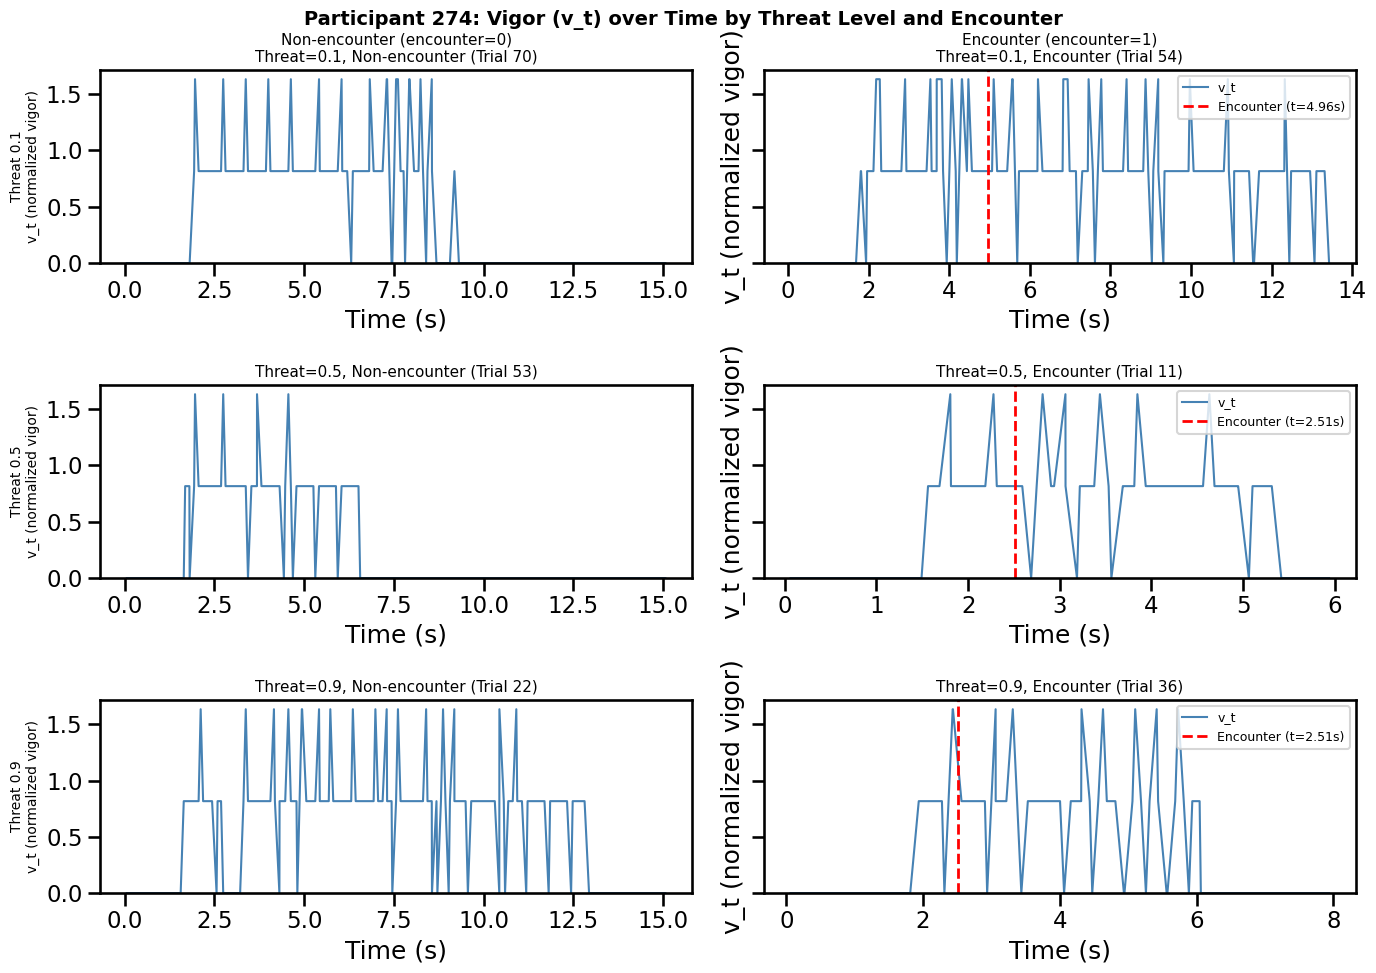

--- Figure 1/5 completed (Participant 274) ---



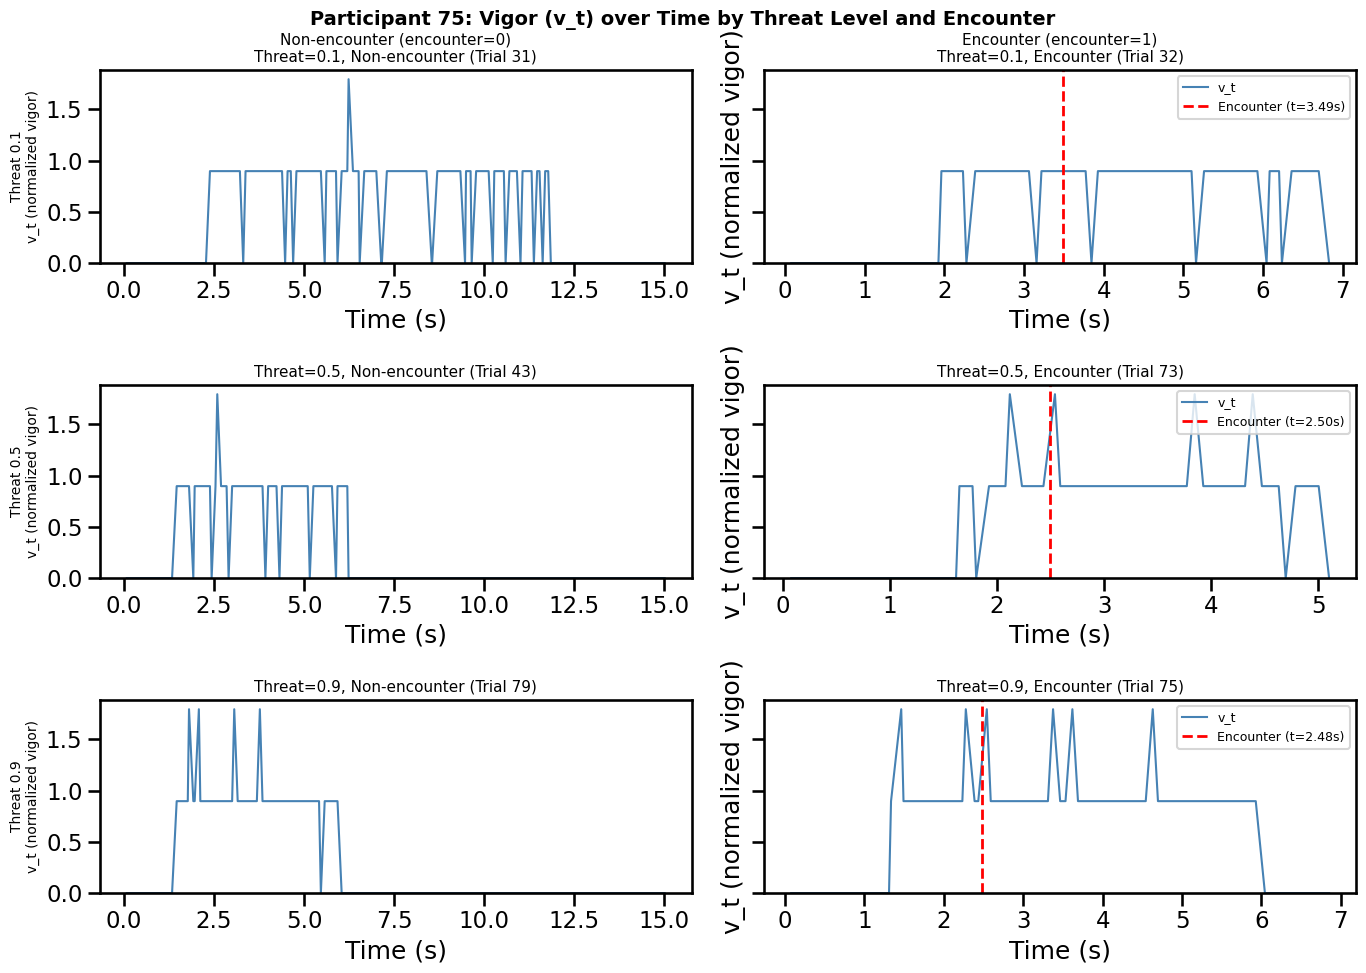

--- Figure 2/5 completed (Participant 75) ---



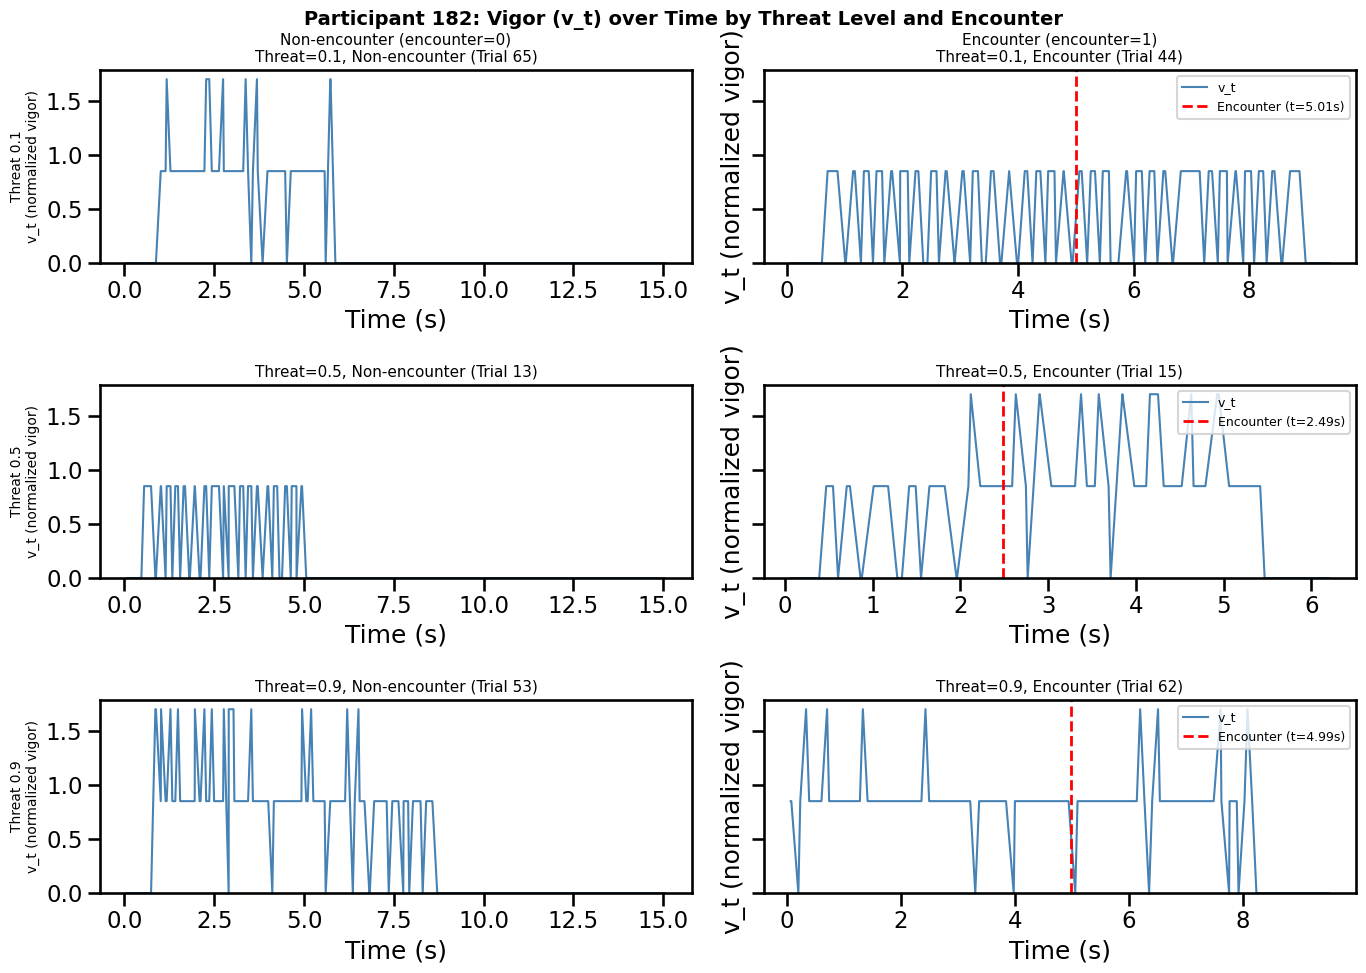

--- Figure 3/5 completed (Participant 182) ---



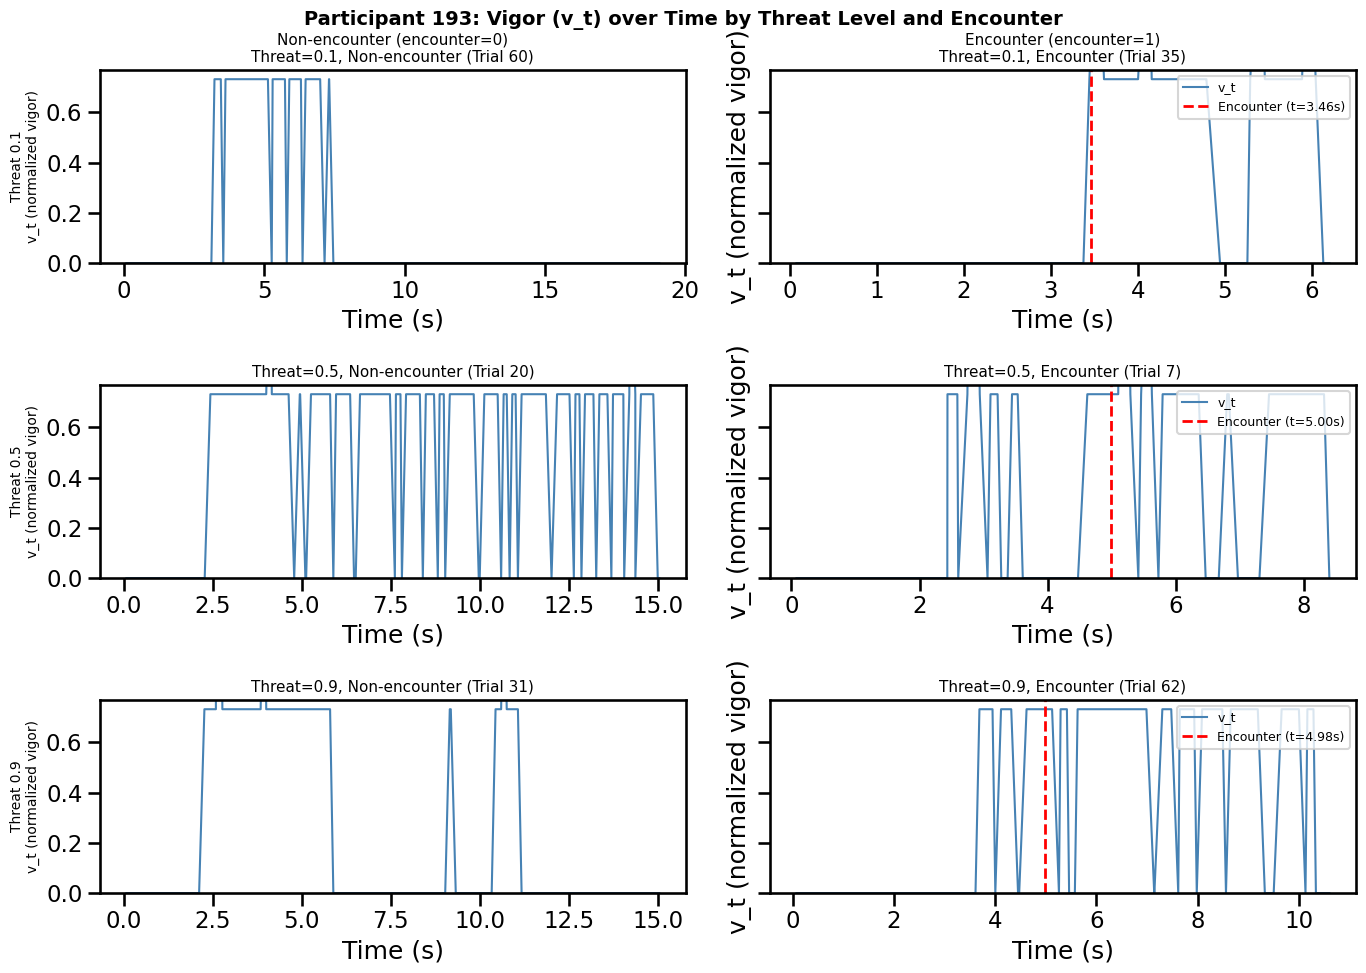

--- Figure 4/5 completed (Participant 193) ---



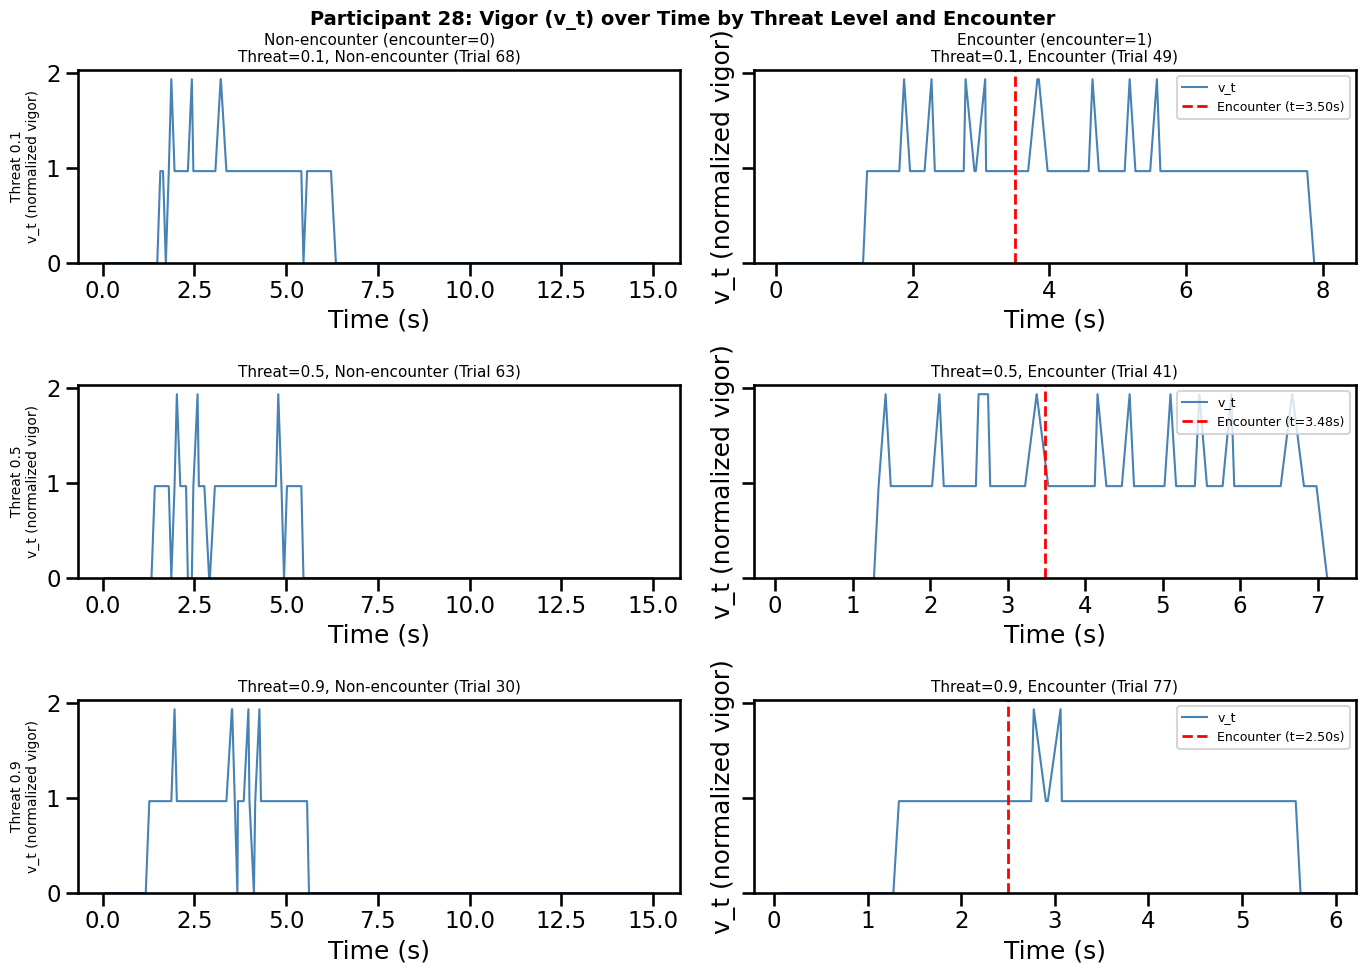

--- Figure 5/5 completed (Participant 28) ---



In [12]:
# --- Generate 5 figures (one per participant)
# Each figure has 6 subplots: 3 rows (threat levels) x 2 cols (encounter=0, encounter=1)

def select_trial(subj_data, threat, encounter, rng):
    """Randomly select one trial matching the given threat and encounter condition."""
    mask = (abs(subj_data["threat"] - threat) < 0.05) & (subj_data["encounter"] == encounter)
    available_trials = subj_data.loc[mask, "trial_id"].unique()
    if len(available_trials) == 0:
        return None
    return rng.choice(available_trials)

for subj_idx, subj_id in enumerate(sampled_subjects):
    subj_data = analysis_table[analysis_table["subj_id"] == subj_id]
    rng = np.random.default_rng(seed=subj_idx)  # Reproducible per-subject randomization
    
    fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=False, sharey=True)
    fig.suptitle(f"Participant {subj_id}: Vigor (v_t) over Time by Threat Level and Encounter", 
                 fontsize=14, fontweight='bold')
    
    for row_idx, threat in enumerate(threat_levels):
        for col_idx, encounter in enumerate([0, 1]):
            ax = axes[row_idx, col_idx]
            
            # Select a random trial for this condition
            trial_id = select_trial(subj_data, threat, encounter, rng)
            
            if trial_id is None:
                ax.text(0.5, 0.5, "No trial available", ha='center', va='center', 
                       transform=ax.transAxes, fontsize=12, color='gray')
                ax.set_title(f"Threat={threat}, Encounter={encounter}")
                continue
            
            # Get trial data
            trial_data = subj_data[subj_data["trial_id"] == trial_id].sort_values("t")
            
            # Plot v_t over time
            ax.plot(trial_data["t"], trial_data["v_t"], linewidth=1.5, color='steelblue', 
                   label='v_t')
            
            # Add vertical line at encounter time (if encounter trial)
            encounter_time = trial_data["encounter_time"].iloc[0]
            if pd.notna(encounter_time) and encounter == 1:
                ax.axvline(x=encounter_time, color='red', linestyle='--', linewidth=2, 
                          label=f'Encounter (t={encounter_time:.2f}s)')
            
            # Labels and title
            enc_label = "Encounter" if encounter == 1 else "Non-encounter"
            ax.set_title(f"Threat={threat}, {enc_label} (Trial {trial_id})", fontsize=11)
            ax.set_xlabel("Time (s)")
            ax.set_ylabel("v_t (normalized vigor)")
            ax.set_ylim(0, None)  # Start y-axis at 0
            
            # Add legend only if encounter line was added
            if pd.notna(encounter_time) and encounter == 1:
                ax.legend(loc='upper right', fontsize=9)
    
    # Add row labels on the left side
    for row_idx, threat in enumerate(threat_levels):
        axes[row_idx, 0].set_ylabel(f"Threat {threat}\nv_t (normalized vigor)", fontsize=10)
    
    # Add column labels
    axes[0, 0].set_title(f"Non-encounter (encounter=0)\n{axes[0,0].get_title()}", fontsize=11)
    axes[0, 1].set_title(f"Encounter (encounter=1)\n{axes[0,1].get_title()}", fontsize=11)
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.show()
    
    print(f"--- Figure {subj_idx + 1}/5 completed (Participant {subj_id}) ---\n")

## 6) Save output

Saves `analysis_table.parquet` for downstream modeling.


In [13]:
# --- Save
analysis_table.to_parquet(OUT_PATH, index=False)
print("Saved:", OUT_PATH, " shape:", analysis_table.shape)


Saved: analysis_table.parquet  shape: (3484910, 27)
